CSV data:
   service_date time_period station_name route_or_line  gated_entries  \
0    9/30/2023  (00:00:00)      Alewife      Red Line            2.0   
1    9/30/2023  (00:00:00)      Airport     Blue Line           46.0   
2    9/30/2023  (00:00:00)     Aquarium     Blue Line           86.0   
3    9/30/2023  (00:00:00)    Arlington    Green Line           55.0   
4    9/30/2023  (00:00:00)     Assembly   Orange Line           16.0   

       stop_id  hour_of_day  day_of_week  is_weekend  month  ...      line_id  \
0  place-alfcl            0            5           1      9  ...     line-Red   
1  place-aport            0            5           1      9  ...    line-Blue   
2  place-aqucl            0            5           1      9  ...    line-Blue   
3  place-armnl            0            5           1      9  ...          NaN   
4  place-astao            0            5           1      9  ...  line-Orange   

      network_id  municipality parent_station  is_transfer_station  \

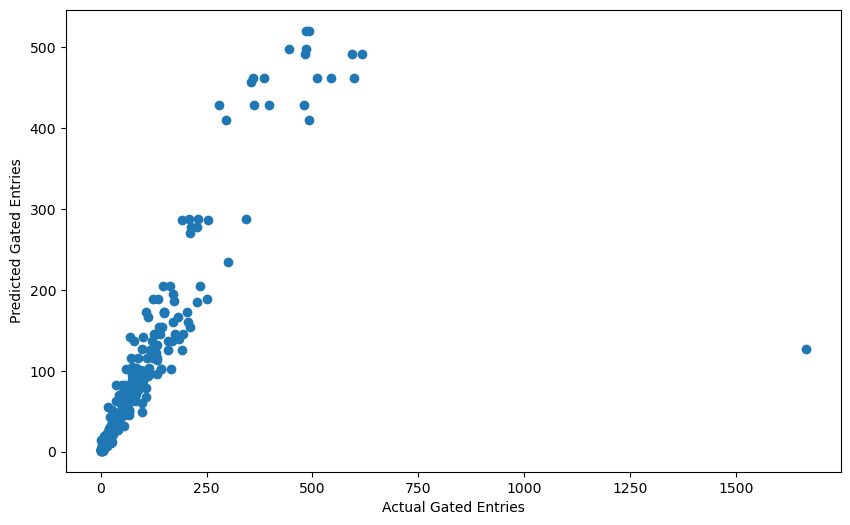

Station Name: Andrew - R²: 0.861


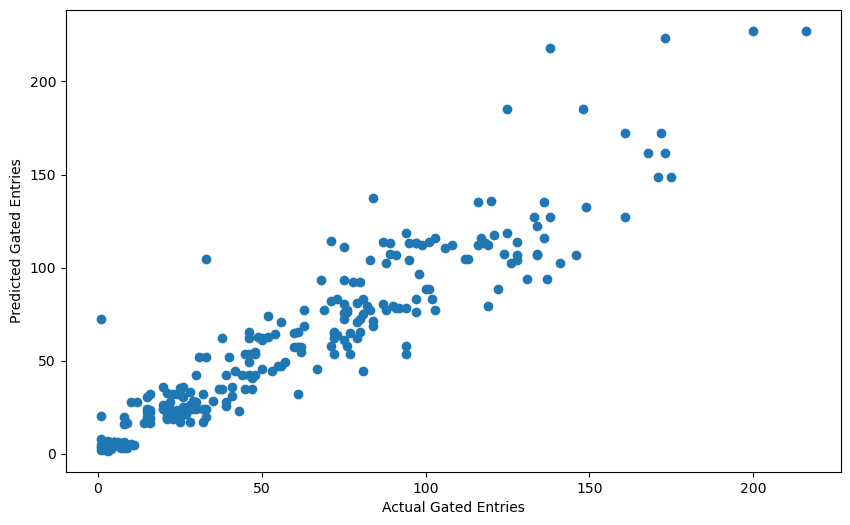

Station Name: Airport - R²: 0.852


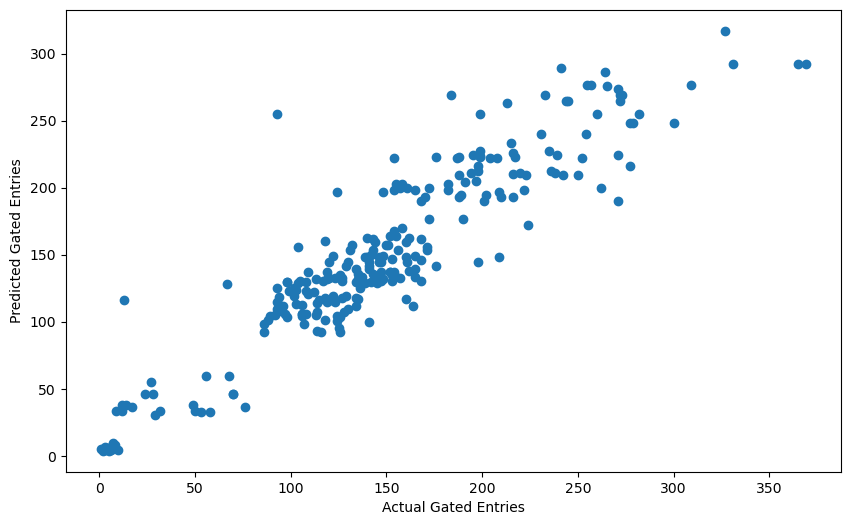

Station Name: Aquarium - R²: 0.918


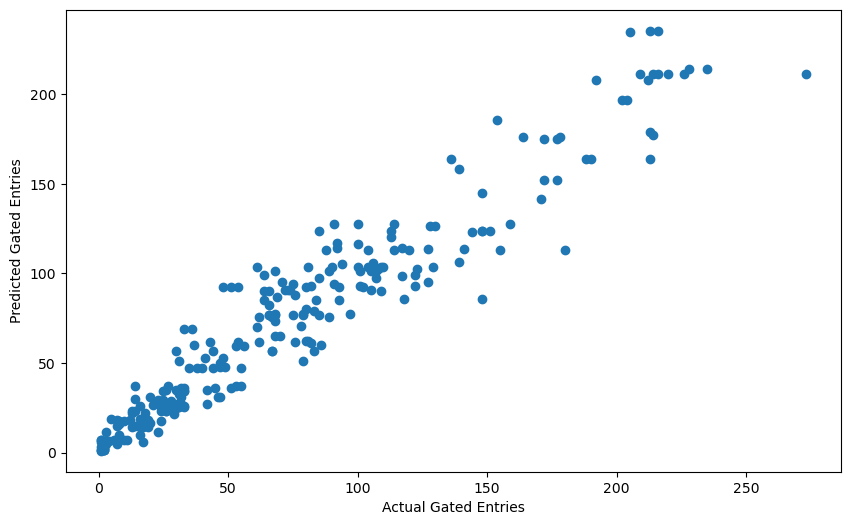

Station Name: Ashmont - R²: 0.919


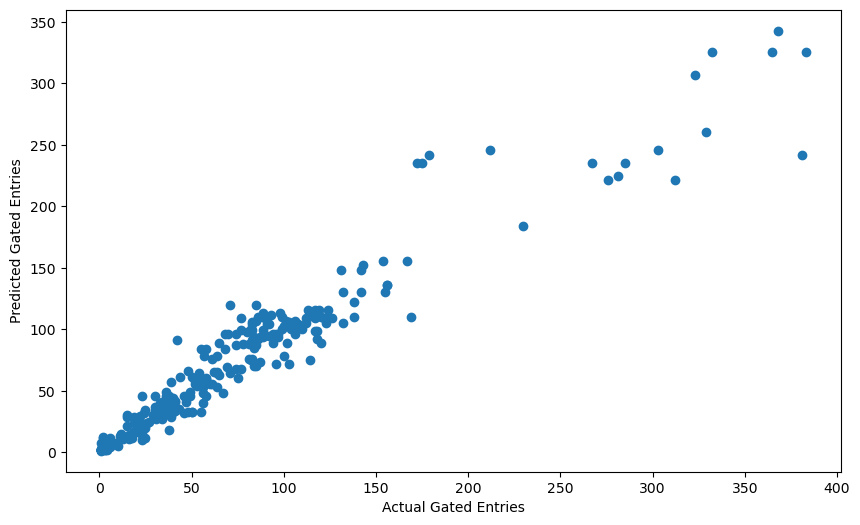

Station Name: Assembly - R²: 0.866


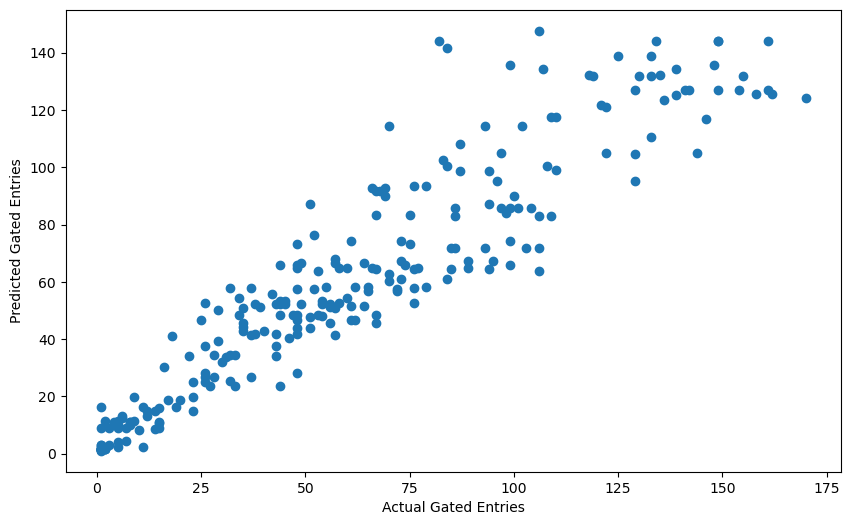

Station Name: Back Bay - R²: 0.901


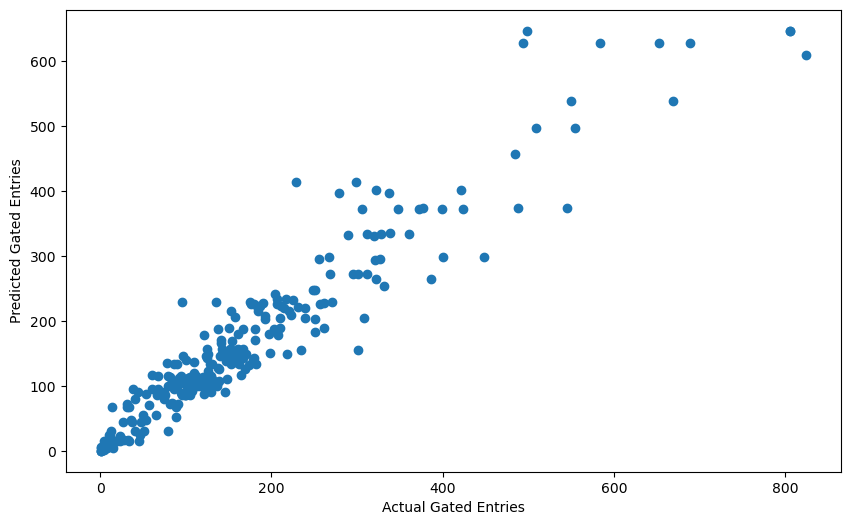

Station Name: Beachmont - R²: 0.918


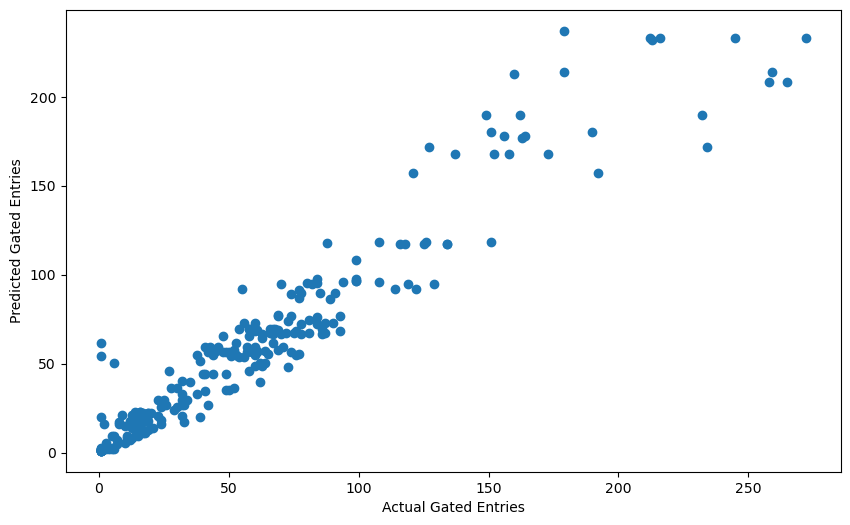

Station Name: Bowdoin - R²: 0.860


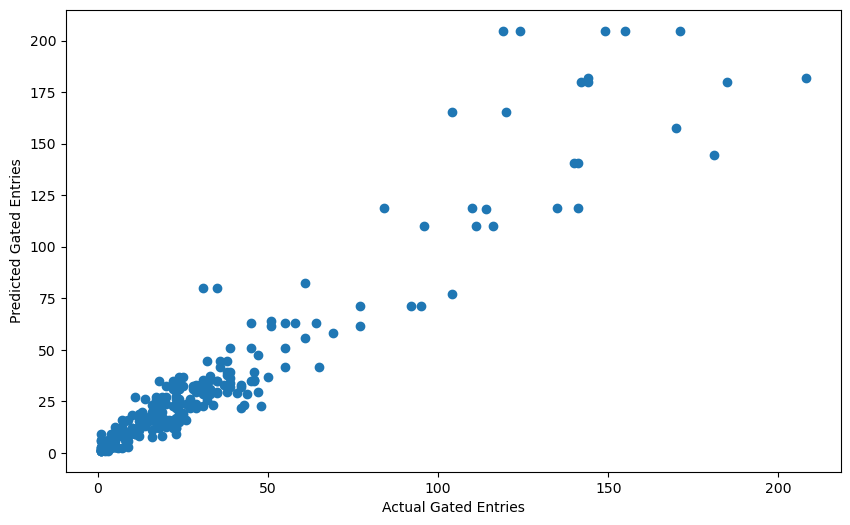

Station Name: Broadway - R²: 0.884


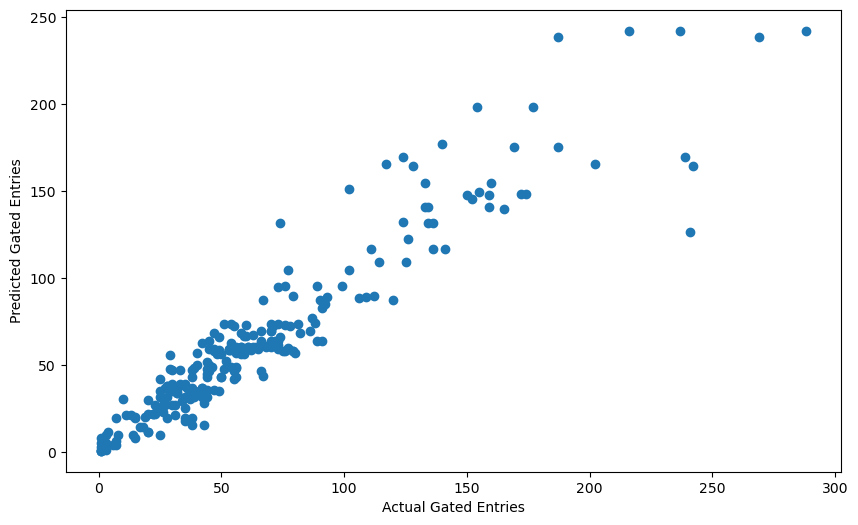

Station Name: Braintree - R²: 0.830


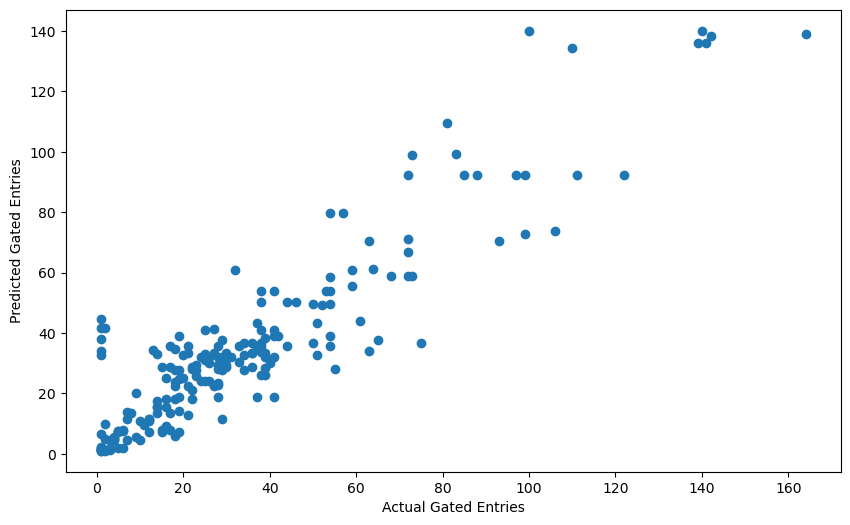

Station Name: Community College - R²: 0.836


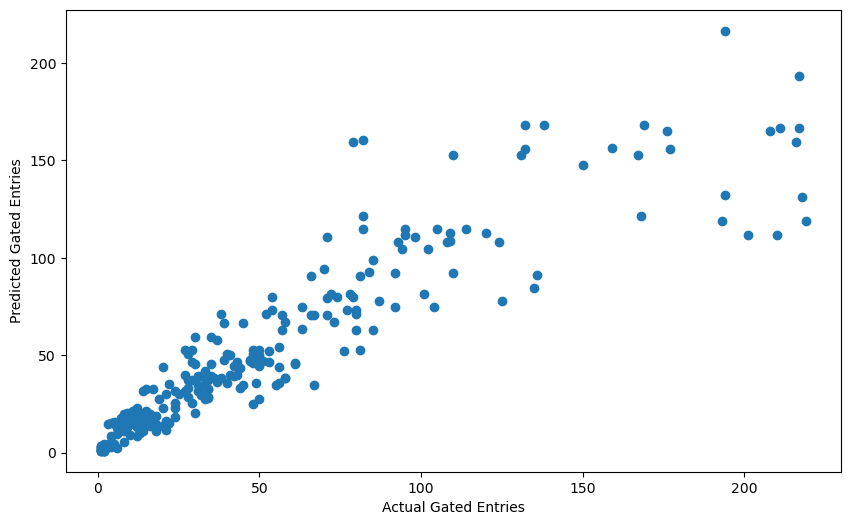

Station Name: Charles/MGH - R²: 0.931


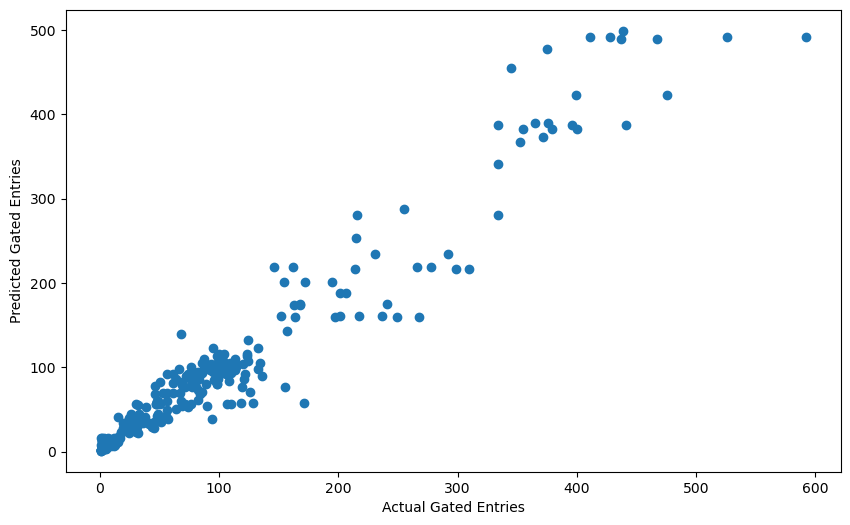

Station Name: Chinatown - R²: 0.894


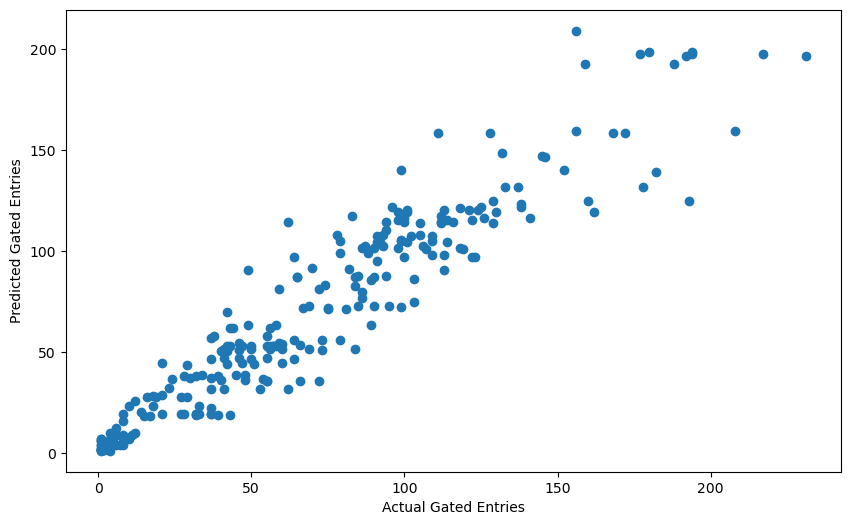

Station Name: Central - R²: 0.928


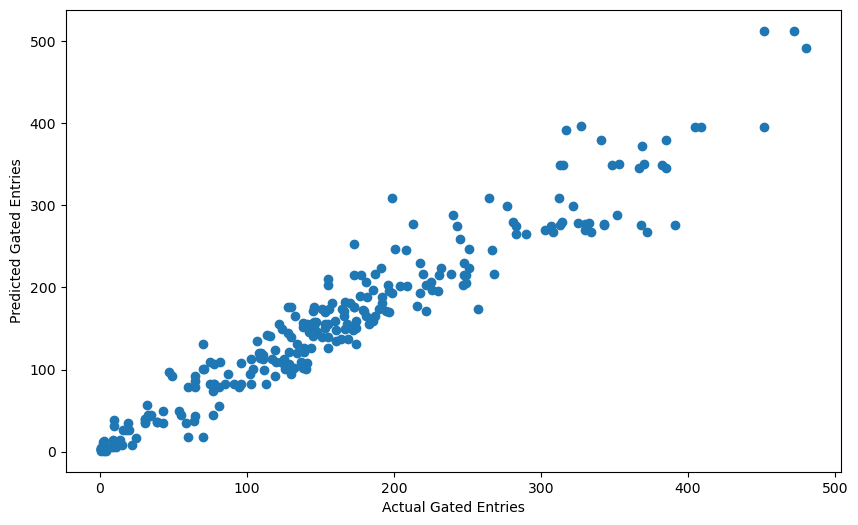

Station Name: Davis - R²: 0.940


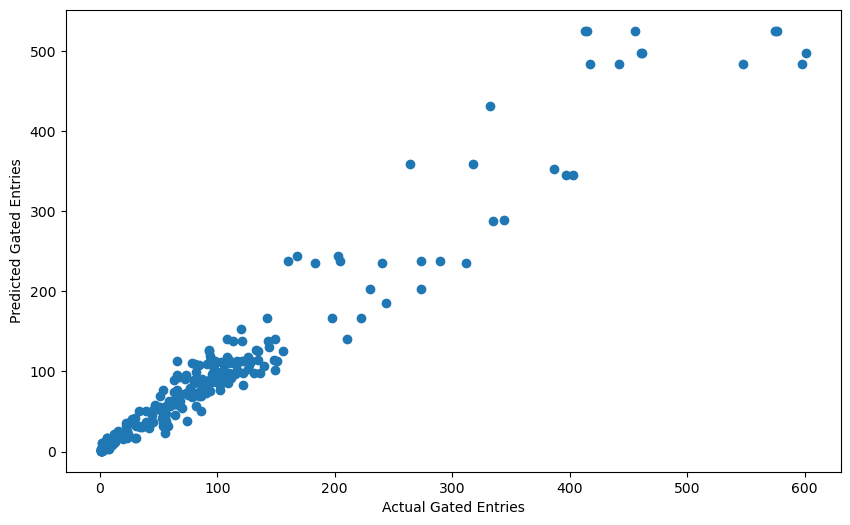

Station Name: Downtown Crossing - R²: 0.952


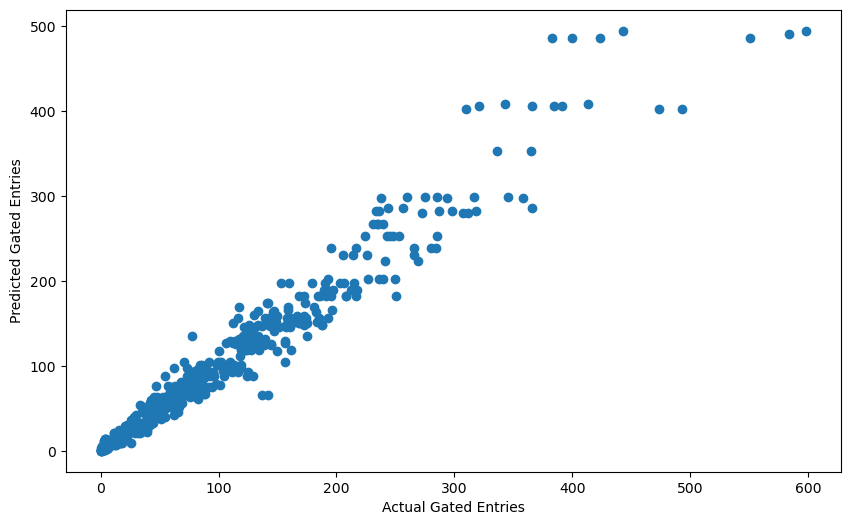

Station Name: Fields Corner - R²: 0.866


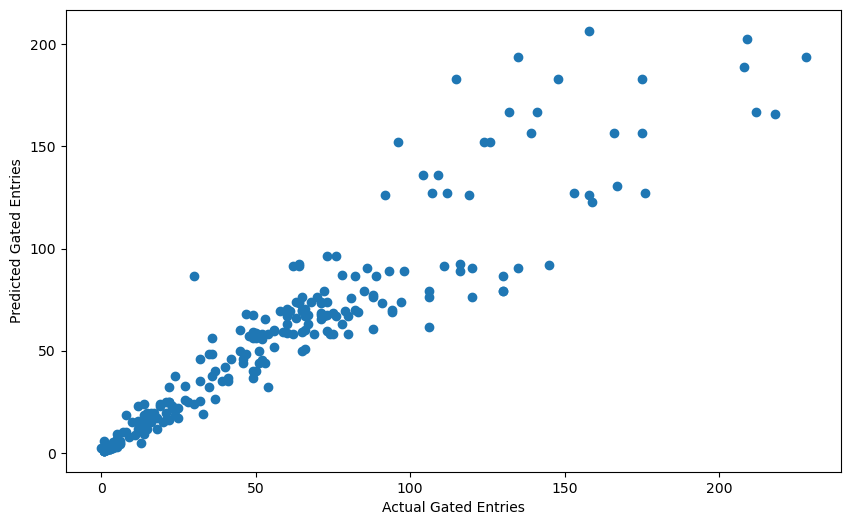

Station Name: Forest Hills - R²: 0.915


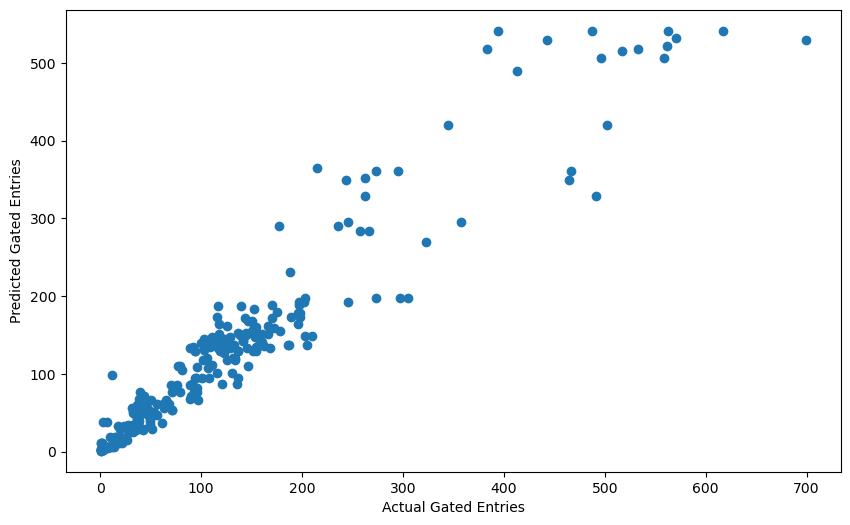

Station Name: Government Center - R²: 0.568


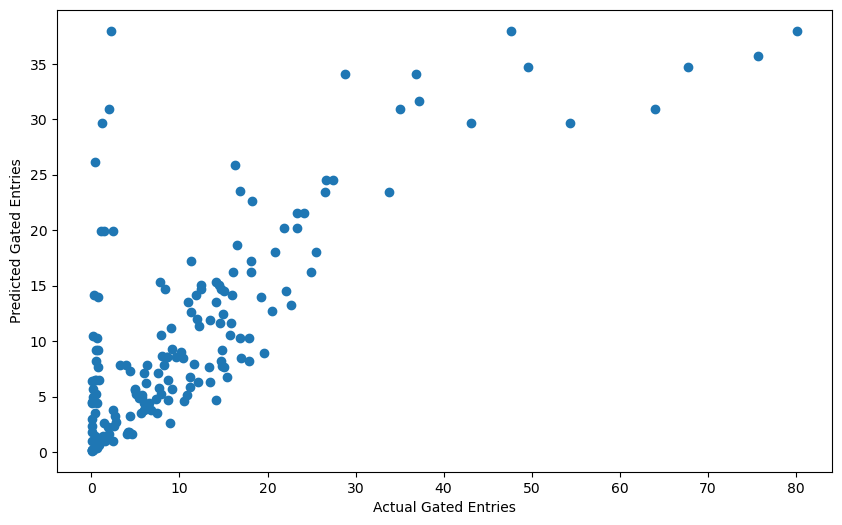

Station Name: Green Street - R²: 0.914


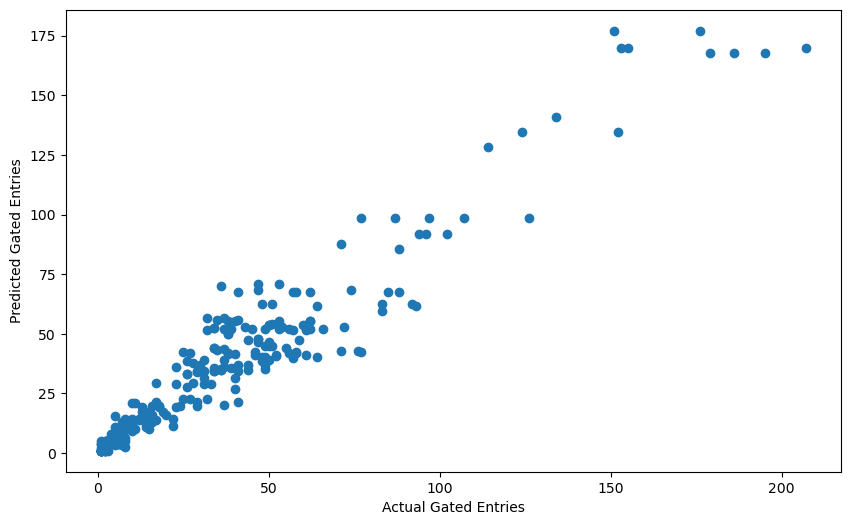

Station Name: Haymarket - R²: 0.504


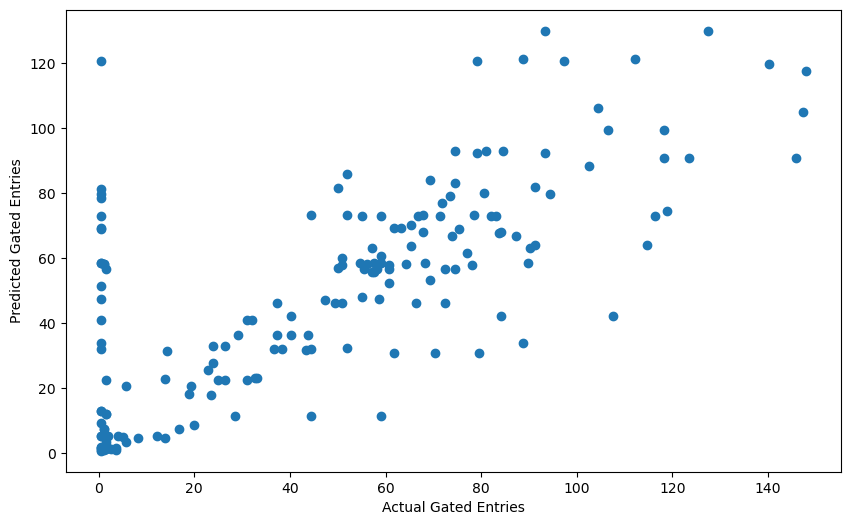

Station Name: Harvard - R²: 0.304


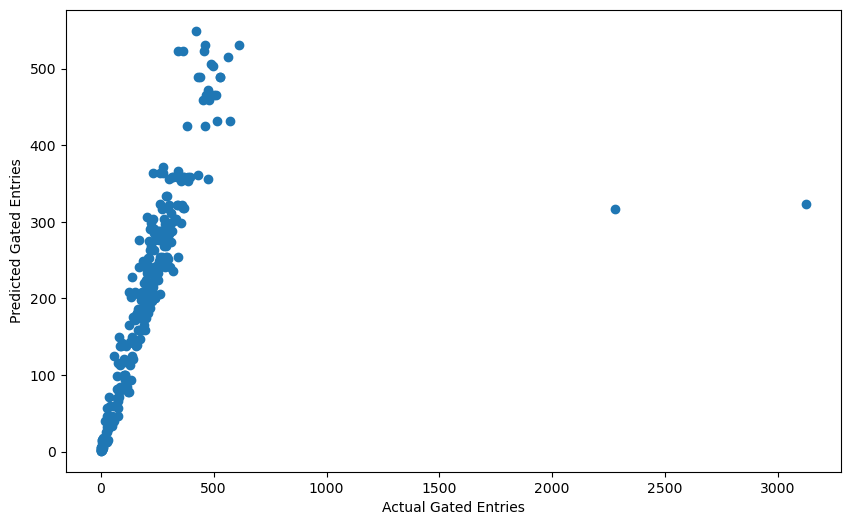

Station Name: Jackson Square - R²: 0.929


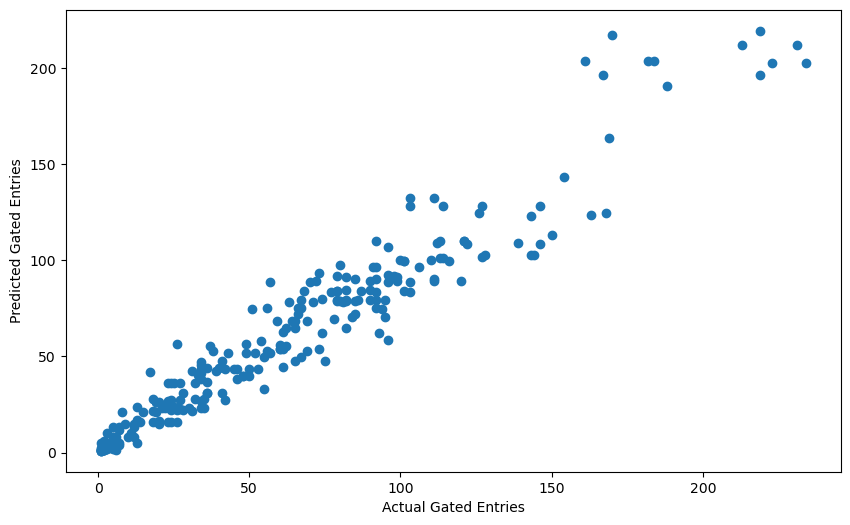

Station Name: JFK/UMass - R²: 0.844


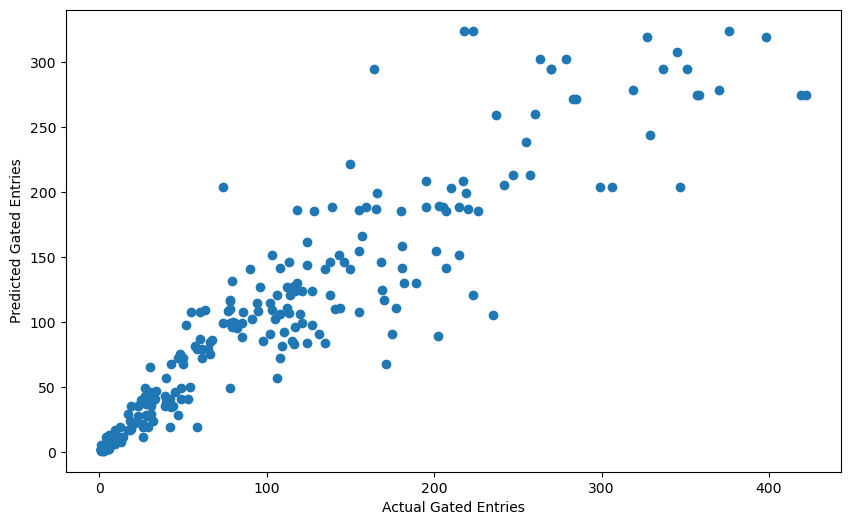

Station Name: Kendall/MIT - R²: 0.916


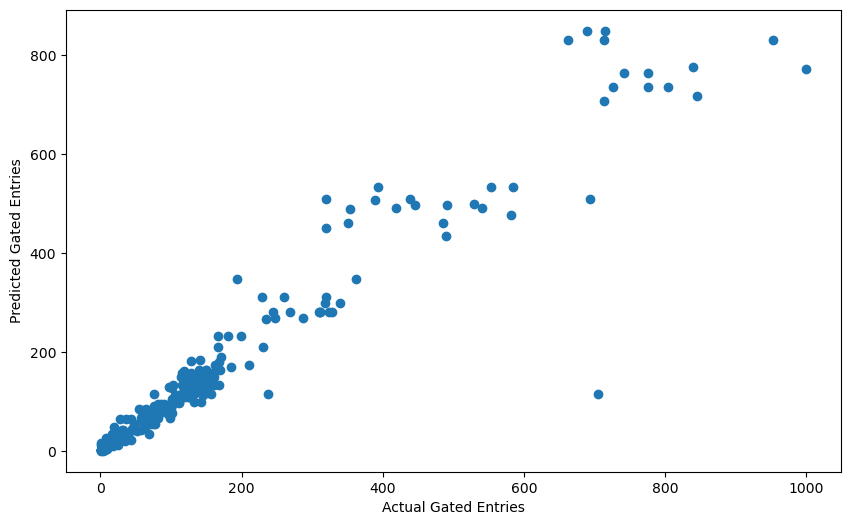

Station Name: Massachusetts Avenue - R²: 0.859


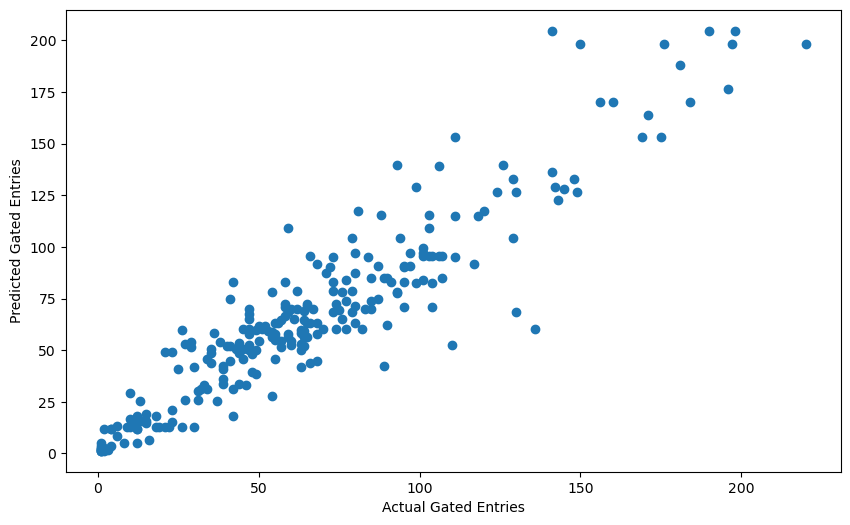

Station Name: Malden Center - R²: 0.951


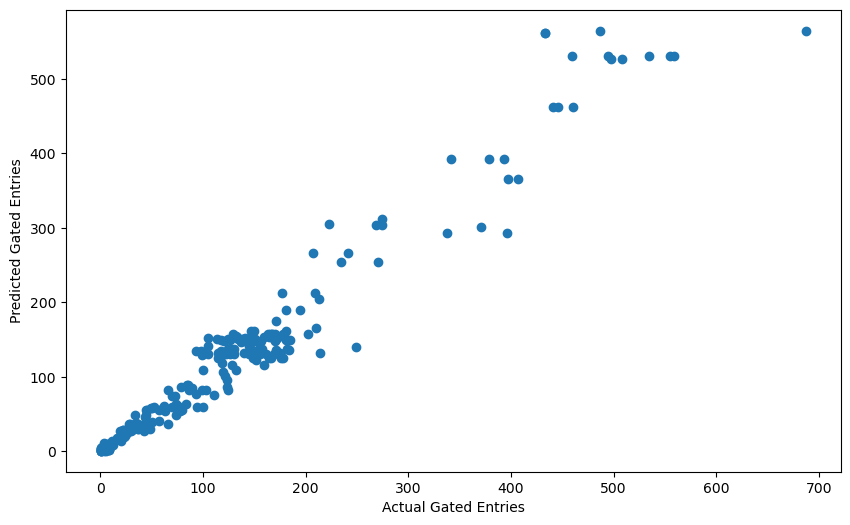

Station Name: Maverick - R²: 0.902


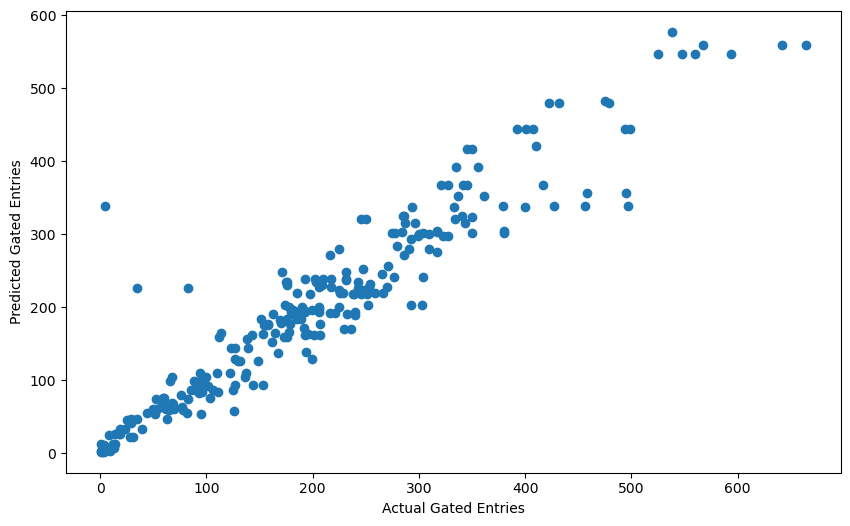

Station Name: North Station - R²: -0.087


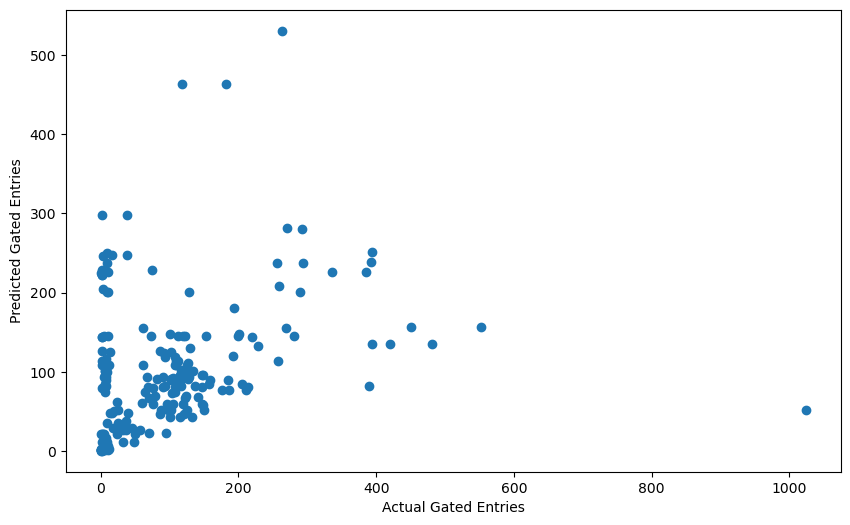

Station Name: North Quincy - R²: 0.842


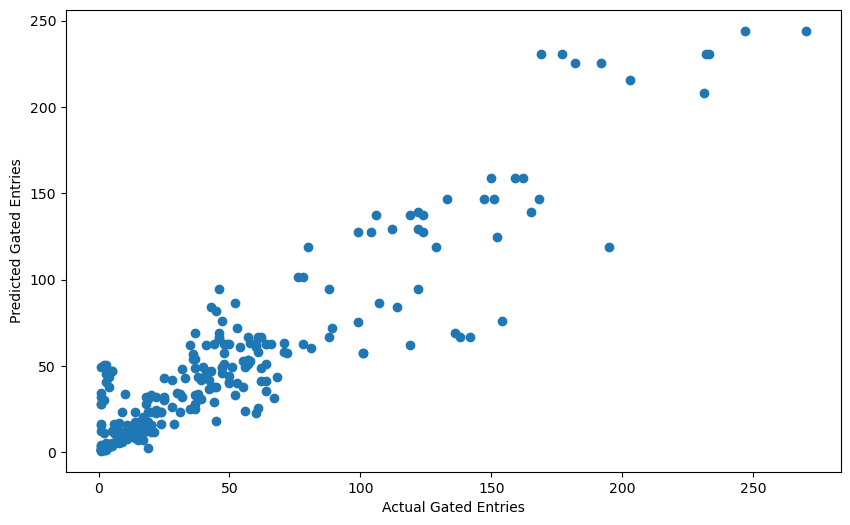

Station Name: Oak Grove - R²: 0.900


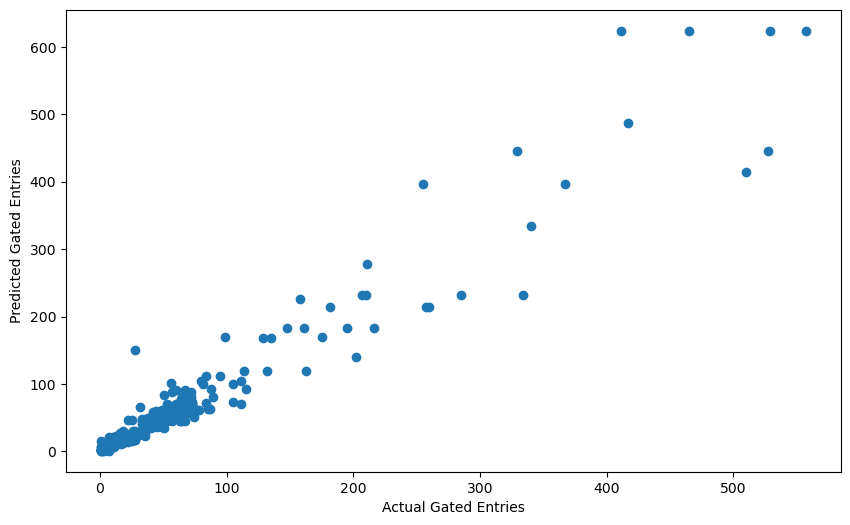

Station Name: Orient Heights - R²: 0.934


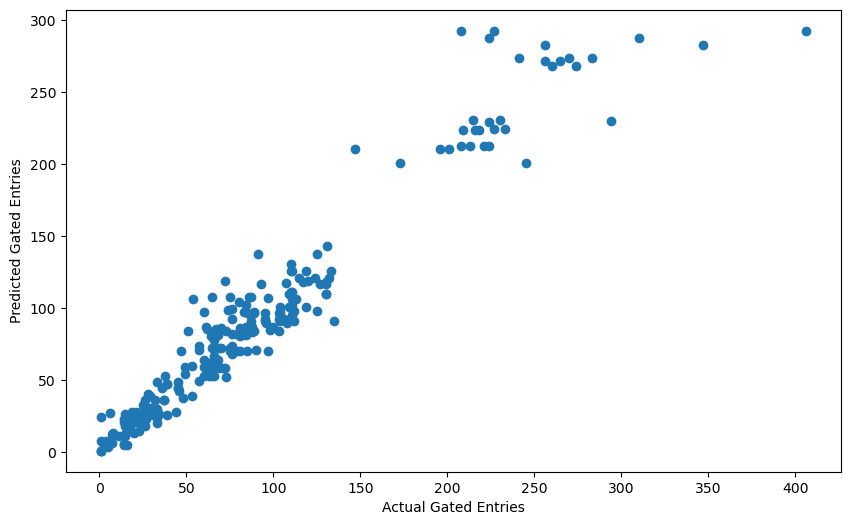

Station Name: Park Street - R²: 0.922


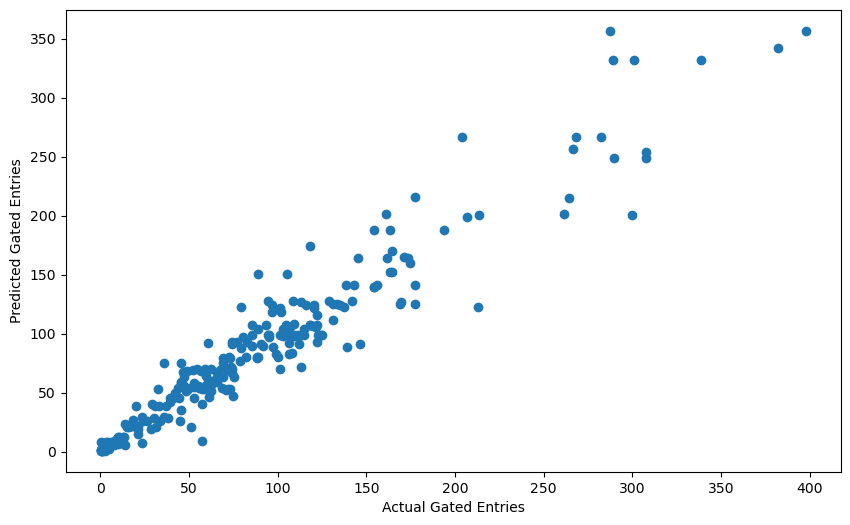

Station Name: Porter - R²: 0.844


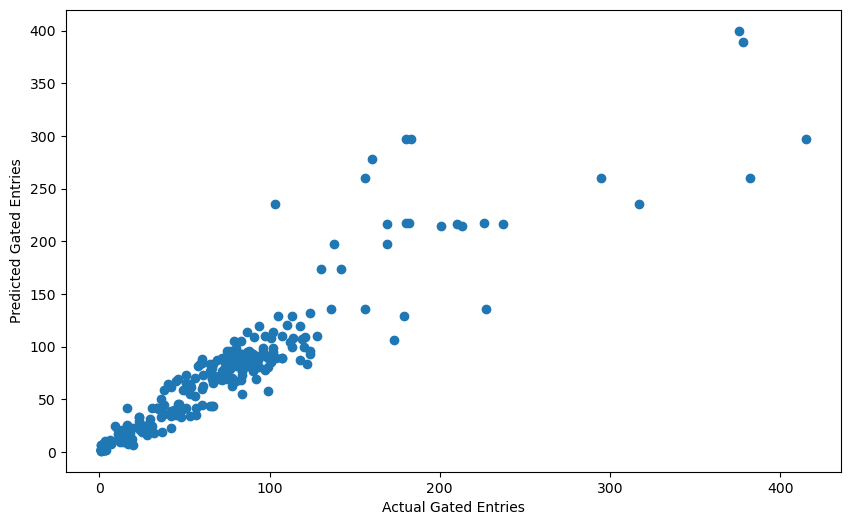

Station Name: Quincy Adams - R²: 0.912


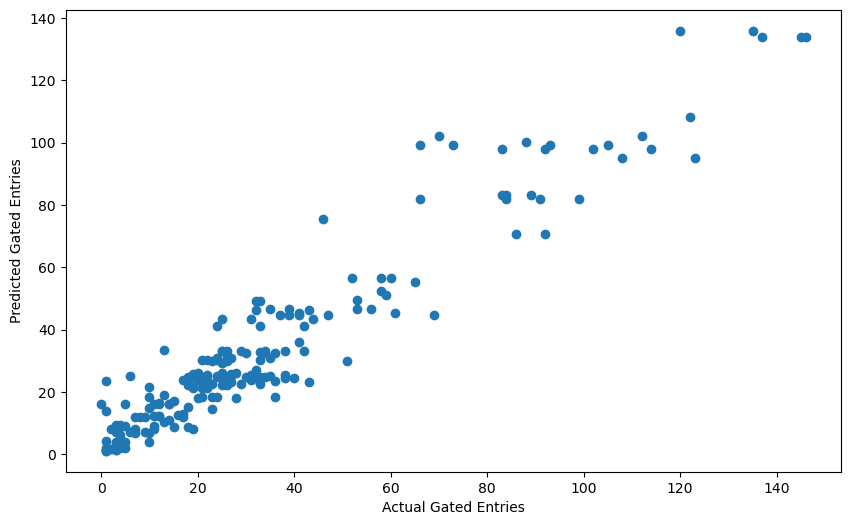

Station Name: Quincy Center - R²: -1.707


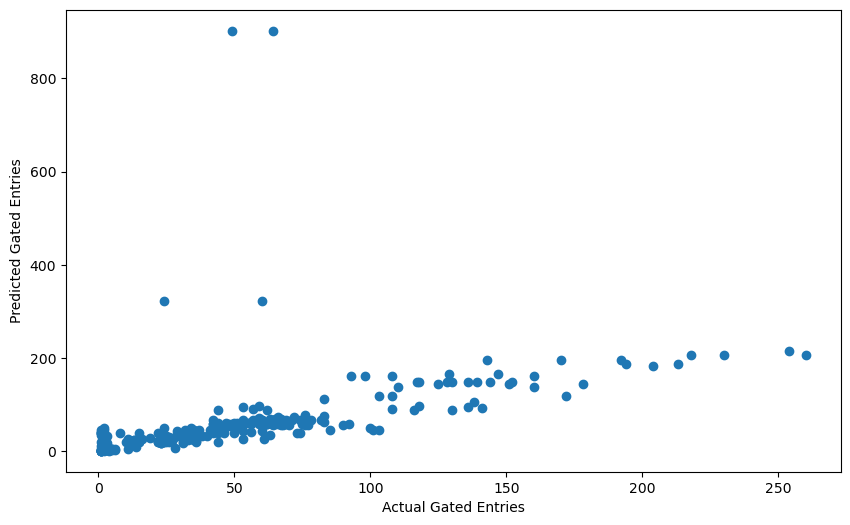

Station Name: Revere Beach - R²: 0.911


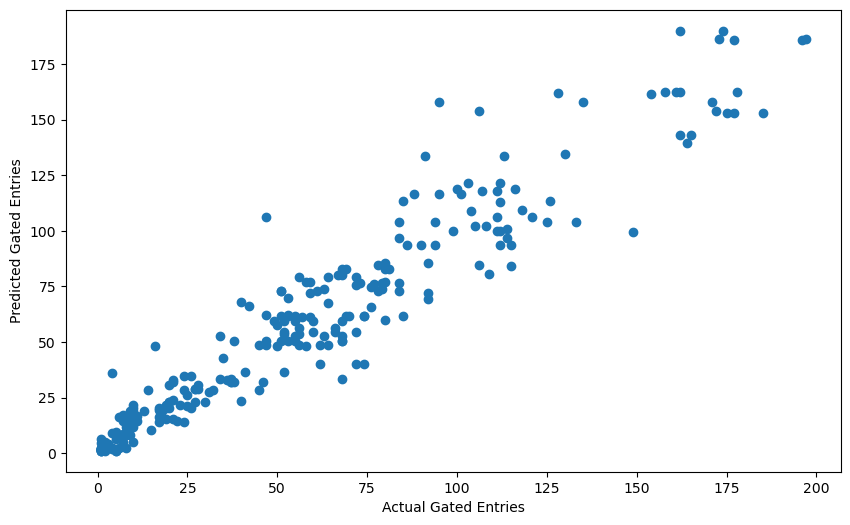

Station Name: Roxbury Crossing - R²: 0.813


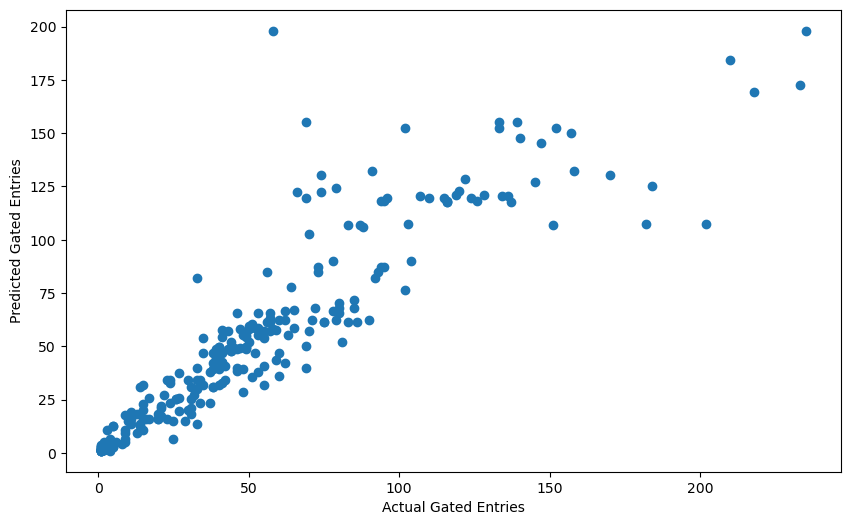

Station Name: Ruggles - R²: 0.897


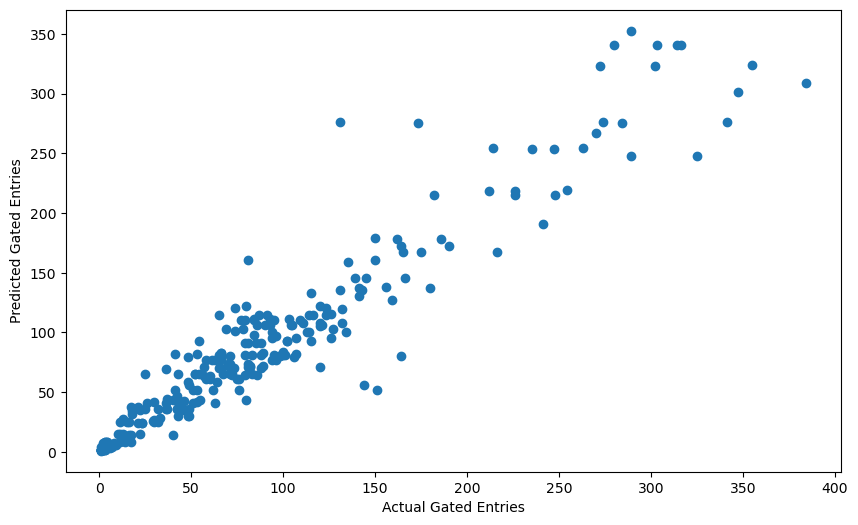

Station Name: Stony Brook - R²: 0.896


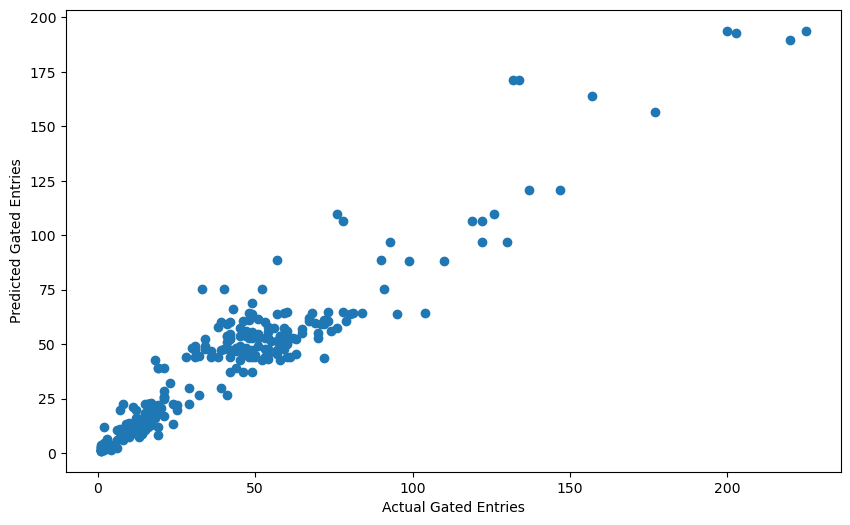

Station Name: Suffolk Downs - R²: 0.729


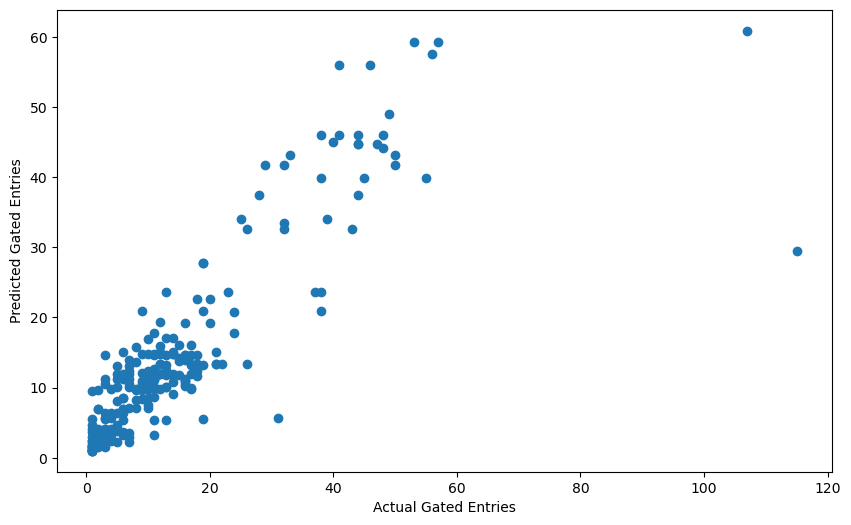

Station Name: Savin Hill - R²: 0.848


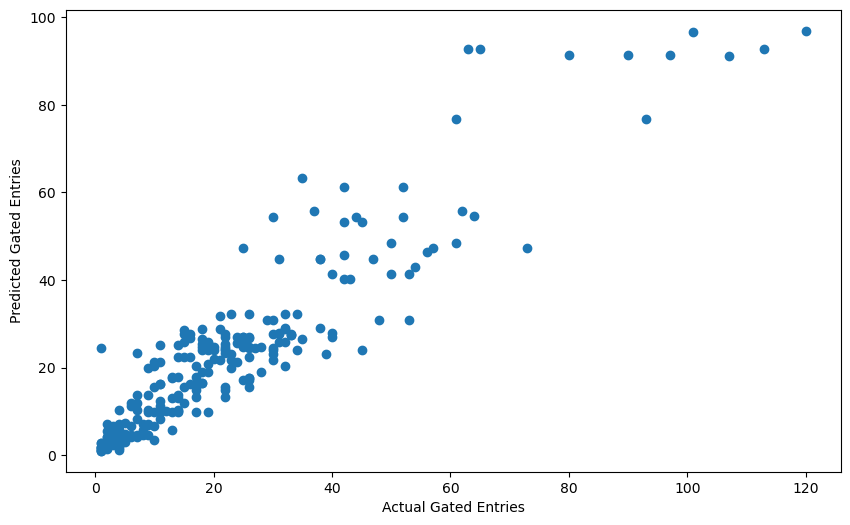

Station Name: Shawmut - R²: 0.876


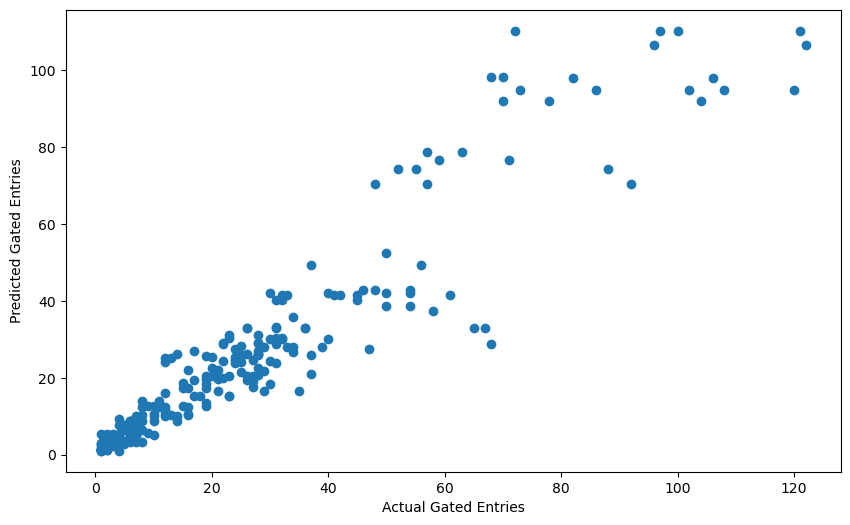

Station Name: South Station - R²: 0.860


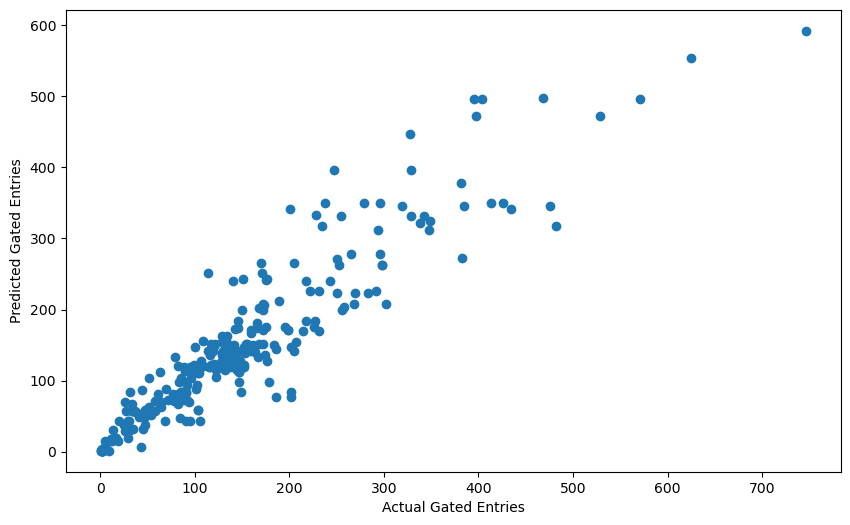

Station Name: State Street - R²: 0.379


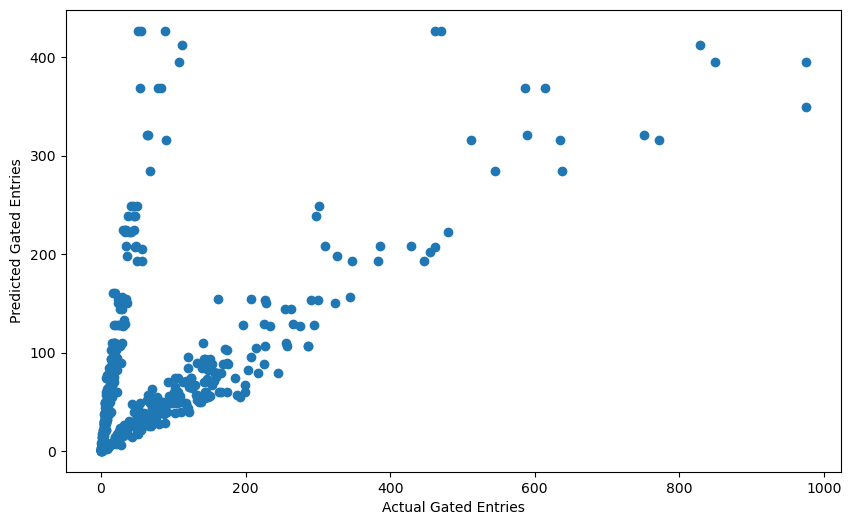

Station Name: Sullivan Square - R²: 0.900


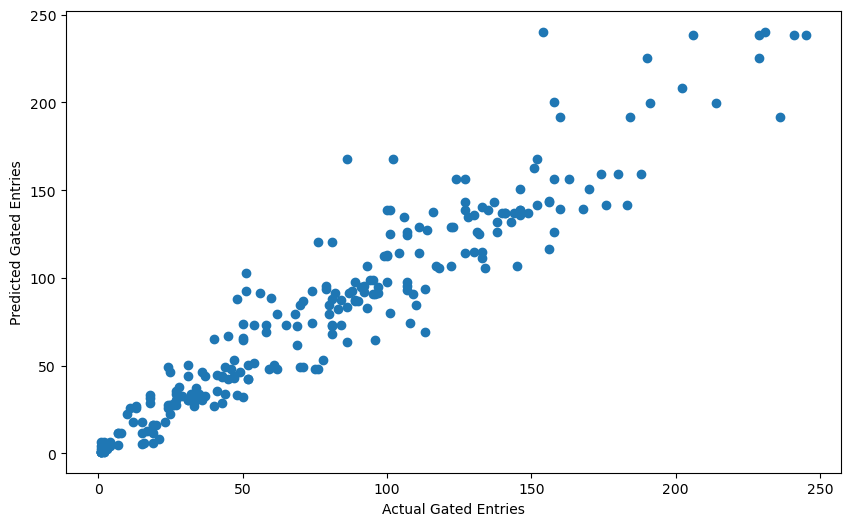

Station Name: Tufts Medical Center - R²: 0.920


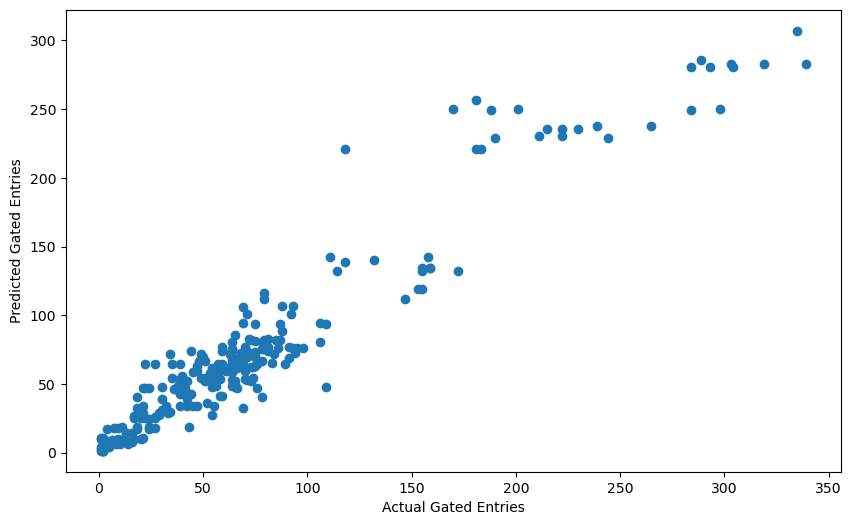

Station Name: Wellington - R²: 0.927


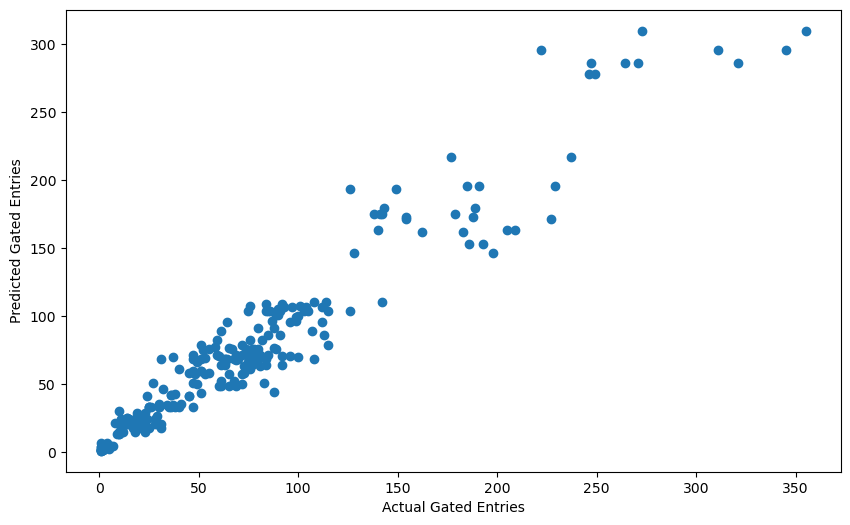

Station Name: Wood Island - R²: 0.837


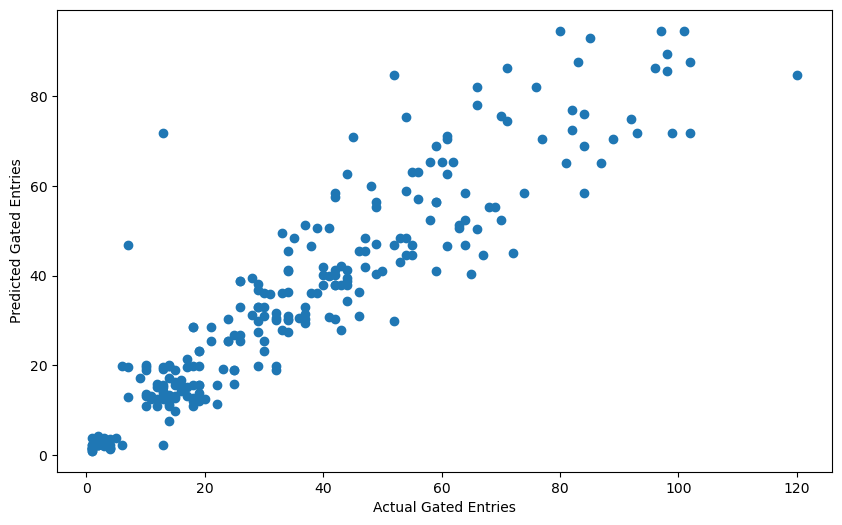

Station Name: Wollaston - R²: 0.911


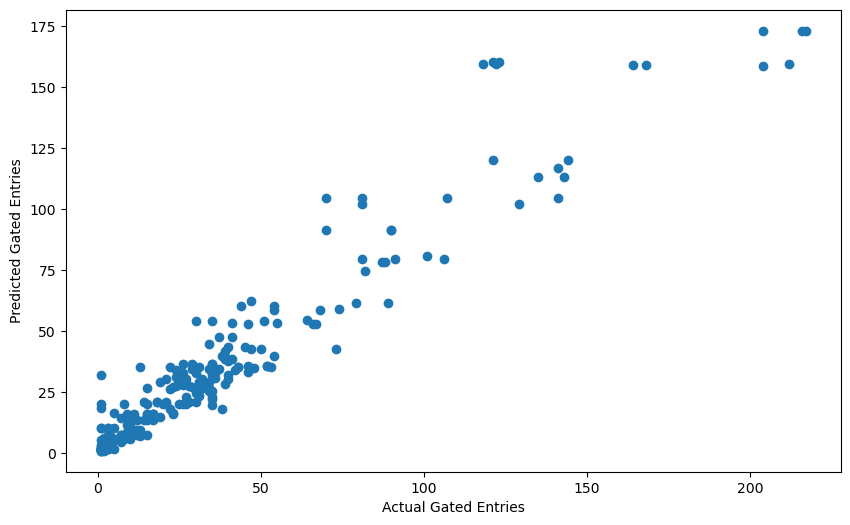

Station Name: Wonderland - R²: 0.935


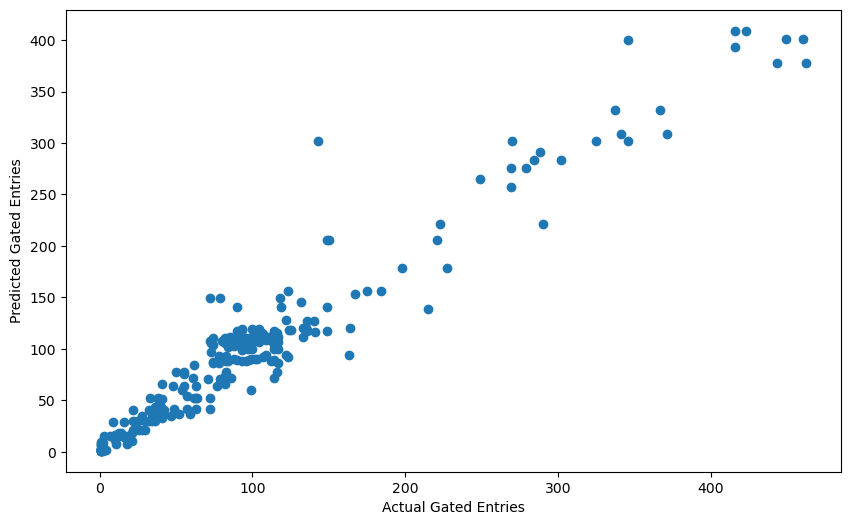

In [2]:
from dataset_get import read_data_csv
from dataset_clean import clean_data
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# get data
data = read_data_csv("../files/2023.9.csv")

# clean data
pre_data = clean_data(data)

for (stop_id, station_name), group_data in pre_data.groupby(['stop_id', 'station_name']):
# get predicted values of the data
    x = group_data[['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_holiday','is_transfer_station','n_routes_at_station','is_multi_route_hub']]
    y = group_data['gated_entries']

    # split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    # train model
    model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print(f"Station Name: {station_name} - R²: {r2:.3f}")


    fig1 =plt.figure(figsize=(10, 6))
    plt.scatter(x=y_test, y=y_pred)
    plt.xlabel("Actual Gated Entries")
    plt.ylabel("Predicted Gated Entries")   
    plt.show()  


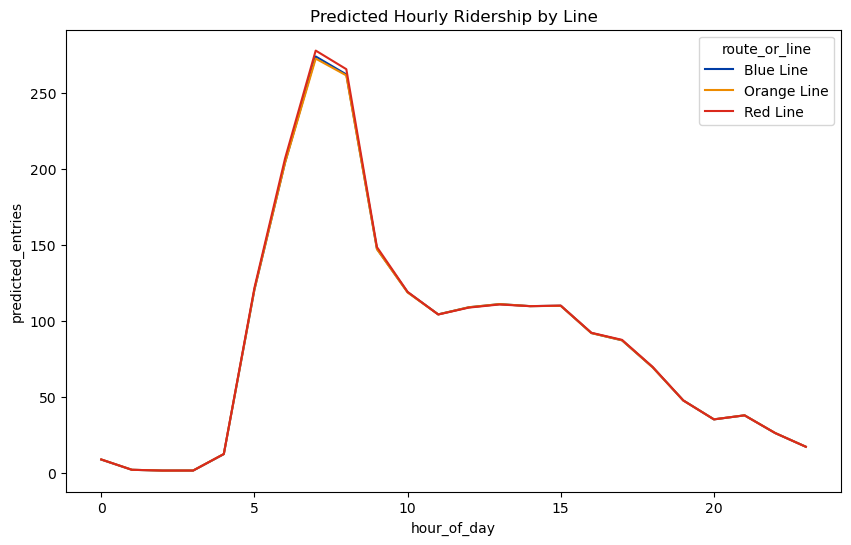

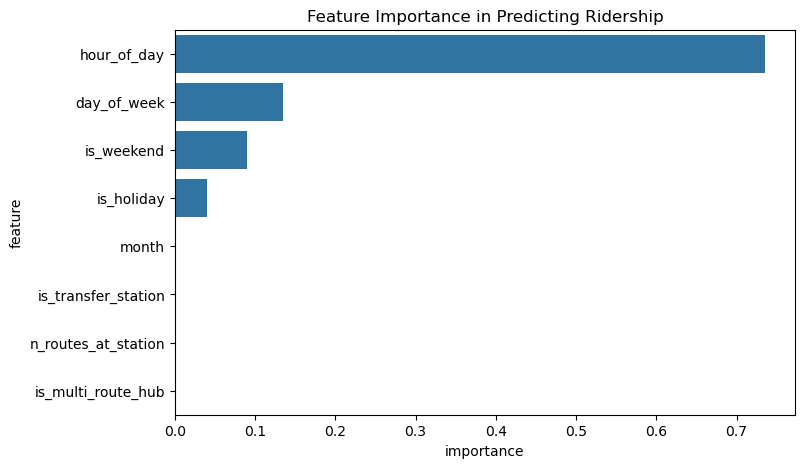

In [38]:
import numpy as np
import pandas as pd
plt.figure(figsize=(10,6))
pic_data = pre_data.groupby(['time', 'route_or_line','route_color'])['gated_entries'].sum().reset_index()
sns.lineplot(x='hour_of_day', y='predicted_entries', hue='route_or_line', palette=pic_data.set_index('route_or_line')['route_color'].to_dict(), data=line_trends)
plt.title('Predicted Hourly Ridership by Line')
plt.show()


importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance in Predicting Ridership')
plt.show()

